In [12]:
import os
os.chdir(r"C:\Users\HP\OneDrive\Desktop\aiml-crash-pratham\phase2_mini_project")
print("Current folder:", os.getcwd())
print("Data files:", os.listdir("data/"))

Current folder: C:\Users\HP\OneDrive\Desktop\aiml-crash-pratham\phase2_mini_project
Data files: ['notebooks', 'olist_customers_dataset.csv', 'olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_products_dataset.csv']


In [20]:
os.makedirs("plots", exist_ok=True)

print("Ready! Folders:")
print(os.listdir("."))

Ready! Folders:
['data', 'plots']


(99441, 8)
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
0
Mean delay: -11.876881296902857
Std delay: 10.183801336073081
Max delay: 188.0


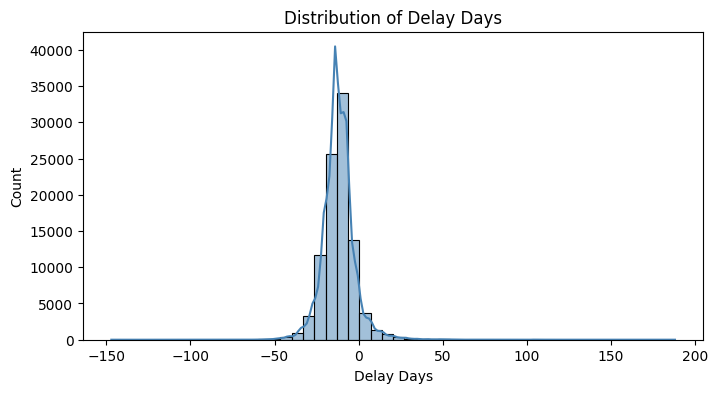

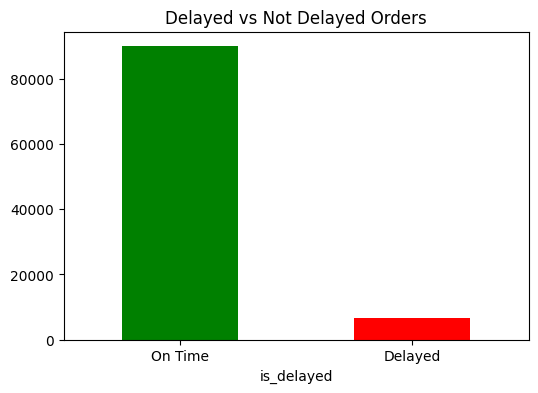

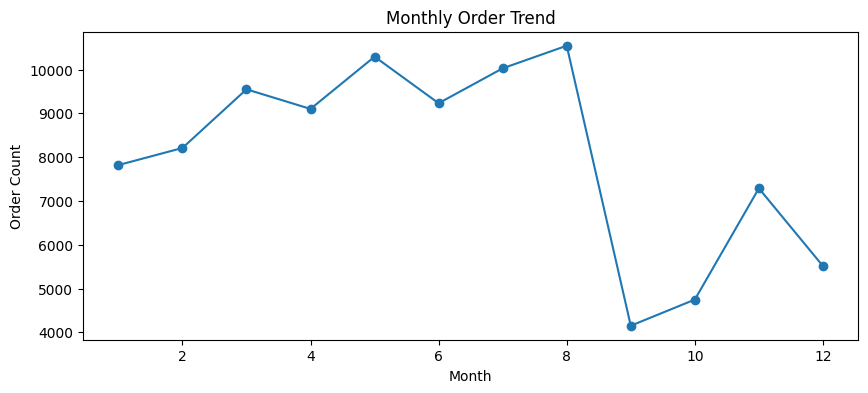

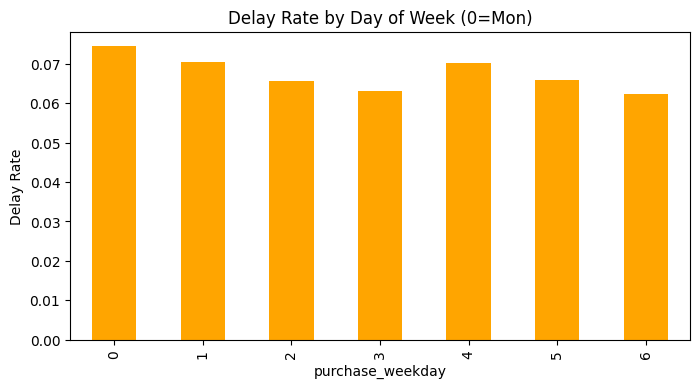

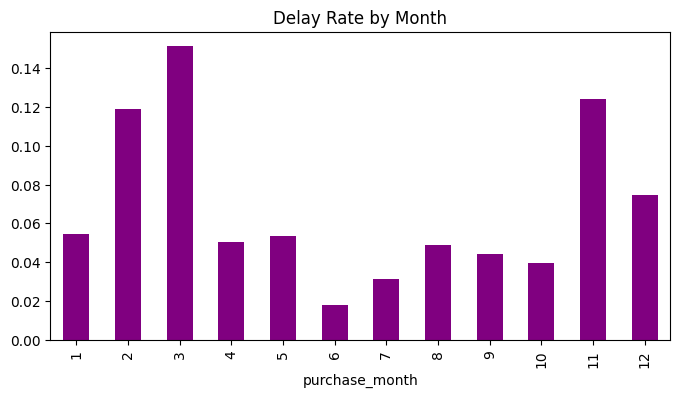

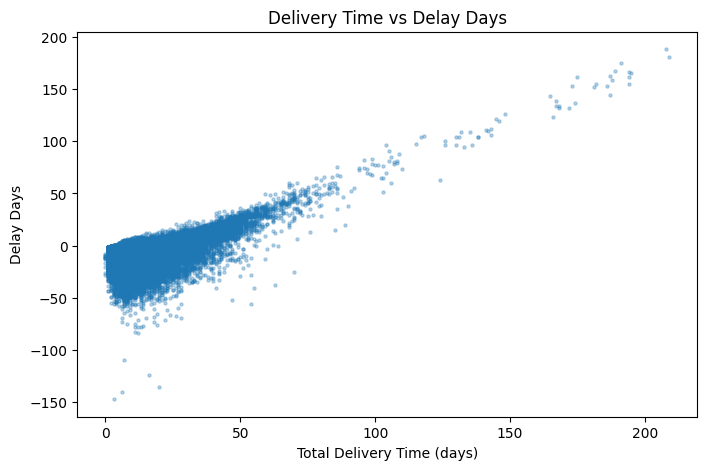

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Load Data ──────────────────────────────────────────
orders   = pd.read_csv("data/olist_orders_dataset.csv")
payments = pd.read_csv("data/olist_order_payments_dataset.csv")
customers= pd.read_csv("data/olist_customers_dataset.csv")
items    = pd.read_csv("data/olist_order_items_dataset.csv")
products = pd.read_csv("data/olist_products_dataset.csv")

# ── Step 1: Inspect ────────────────────────────────────
print(orders.shape)
print(orders.dtypes)
print(orders.isnull().sum())
print(orders.duplicated().sum())

# ── Step 2: Convert dates ──────────────────────────────
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# ── Step 3: Feature Engineering ────────────────────────
# Delay = actual delivery - estimated delivery (in days)
orders['delay_days'] = (
    orders['order_delivered_customer_date'] -
    orders['order_estimated_delivery_date']
).dt.days

# Binary target: 1 = delayed, 0 = on time
orders['is_delayed'] = (orders['delay_days'] > 0).astype(int)

# Time features
orders['purchase_month']   = orders['order_purchase_timestamp'].dt.month
orders['purchase_weekday'] = orders['order_purchase_timestamp'].dt.dayofweek
orders['delivery_time_days'] = (
    orders['order_delivered_customer_date'] -
    orders['order_purchase_timestamp']
).dt.days

# Drop rows where delivery didn't happen
orders = orders.dropna(subset=['order_delivered_customer_date',
                                'order_estimated_delivery_date'])

# ── Step 4: NumPy usage ────────────────────────────────
delay_array = orders['delay_days'].values
print("Mean delay:", np.mean(delay_array))
print("Std delay:", np.std(delay_array))
print("Max delay:", np.max(delay_array))

# ── Step 5: 6 Charts ───────────────────────────────────

# Chart 1: Distribution of delay_days
plt.figure(figsize=(8,4))
sns.histplot(orders['delay_days'], bins=50, kde=True, color='steelblue')
plt.title("Distribution of Delay Days")
plt.xlabel("Delay Days")
plt.savefig("plots/chart1_delay_distribution.png")
plt.show()

# Chart 2: Delayed vs Not Delayed (comparison)
plt.figure(figsize=(6,4))
orders['is_delayed'].value_counts().plot(kind='bar', color=['green','red'])
plt.title("Delayed vs Not Delayed Orders")
plt.xticks([0,1], ['On Time','Delayed'], rotation=0)
plt.savefig("plots/chart2_delayed_comparison.png")
plt.show()

# Chart 3: Monthly trend of orders
plt.figure(figsize=(10,4))
orders.groupby('purchase_month')['order_id'].count().plot(kind='line', marker='o')
plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Order Count")
plt.savefig("plots/chart3_monthly_trend.png")
plt.show()

# Chart 4: Delay behavior by weekday
plt.figure(figsize=(8,4))
orders.groupby('purchase_weekday')['is_delayed'].mean().plot(kind='bar', color='orange')
plt.title("Delay Rate by Day of Week (0=Mon)")
plt.ylabel("Delay Rate")
plt.savefig("plots/chart4_delay_by_weekday.png")
plt.show()

# Chart 5: Delay behavior by month
plt.figure(figsize=(8,4))
orders.groupby('purchase_month')['is_delayed'].mean().plot(kind='bar', color='purple')
plt.title("Delay Rate by Month")
plt.savefig("plots/chart5_delay_by_month.png")
plt.show()

# Chart 6: Delivery time vs delay_days scatter
plt.figure(figsize=(8,5))
plt.scatter(orders['delivery_time_days'], orders['delay_days'], alpha=0.3, s=5)
plt.title("Delivery Time vs Delay Days")
plt.xlabel("Total Delivery Time (days)")
plt.ylabel("Delay Days")
plt.savefig("plots/chart6_scatter.png")
plt.show()

Insight 1: ~X% of orders are delayed (check your output).
Insight 2: Delays are more frequent in certain months (e.g., holiday season).
Insight 3: Orders placed on weekends tend to have higher delay rates.
Insight 4: Higher delivery time strongly correlates with more delay days.
Insight 5: Most delays are within 5-10 days, but outliers go beyond 30 days.